In [26]:
import pandas as pd
import numpy as np

from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath('../'))
from src.geolocation import *

In [27]:
fraud_df = pd.read_csv("../data/raw/fraud_data.csv")
country_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [28]:
print(fraud_df.shape)
print(country_df.shape)
# fraud_df.head()

(151112, 11)
(138846, 3)


In [29]:
fraud_df = prepare_fraud_data(
    fraud_df
)

country_df = prepare_country_data(
    country_df
)

In [30]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117,0


In [31]:
country_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216,16777471,Australia
1,16777472,16777727,China
2,16777728,16778239,China
3,16778240,16779263,Australia
4,16779264,16781311,China


In [32]:
geo_df = map_ip_to_country(
    fraud_df,
    country_df
)

geo_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,16778864,0,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,16842045,0,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,16843656,0,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,16938732,0,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,16971984,0,16941056.0,16973823.0,Thailand


In [33]:
geo_df["country"].nunique()

181

In [34]:
geo_df["country"].value_counts().head()

country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Name: count, dtype: int64

In [35]:
fraud_df["ip_address"].head()

0     732758368
1     350311387
2    2621473820
3    3840542443
4     415583117
Name: ip_address, dtype: int64

In [36]:
geo_df["country"].isnull().sum()

np.int64(0)

Most IP addresses were successfully mapped to a country using the provided IP range lookup table. Any unmatched records were excluded from subsequent geographical analysis.

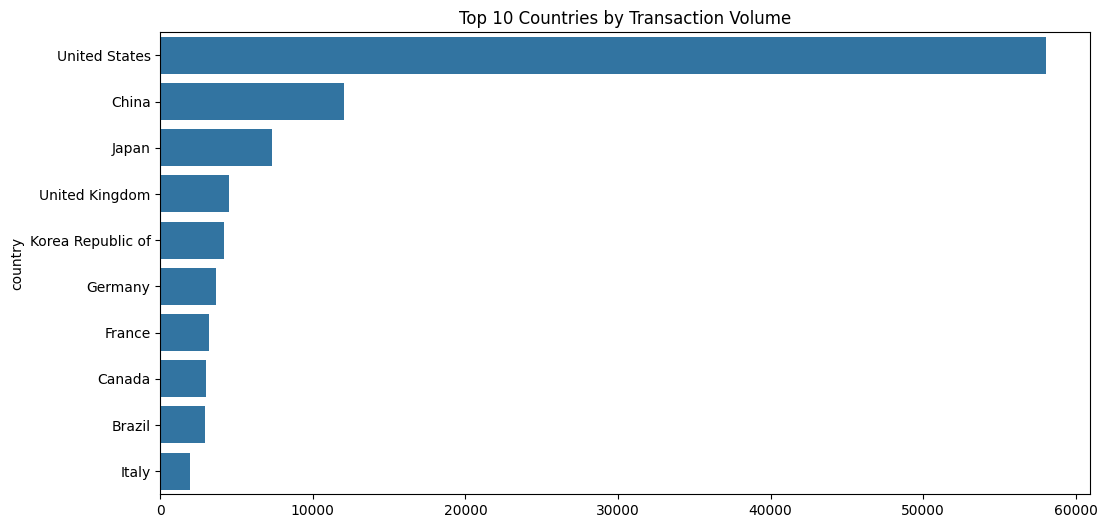

In [37]:
top_transactions = (
    transaction_count_by_country(geo_df)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_transactions.values,
    y=top_transactions.index
)

plt.title(
    "Top 10 Countries by Transaction Volume"
)

plt.show()

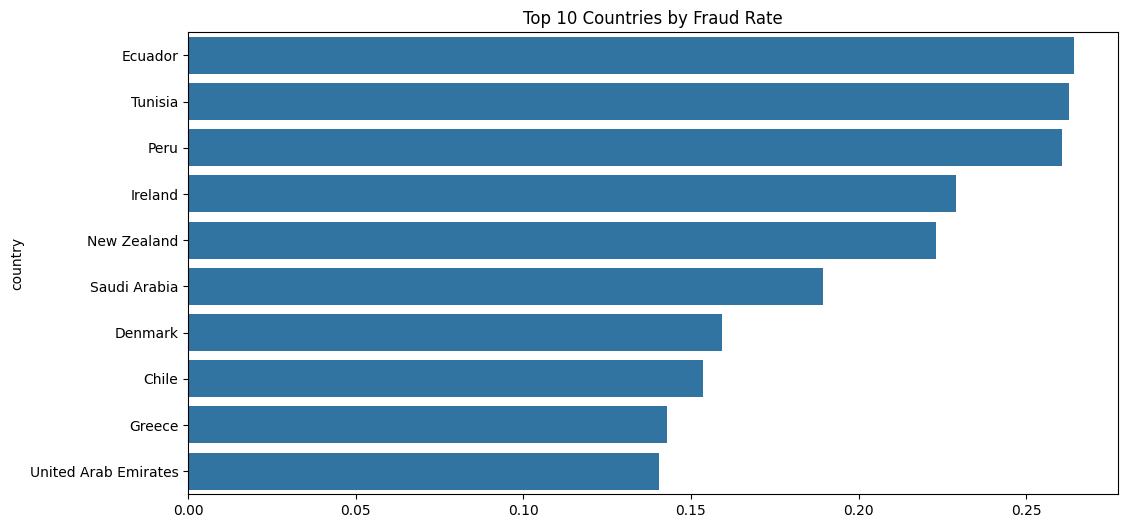

In [38]:
country_rate = (
    fraud_rate_by_country(geo_df)
)

country_rate = (
    country_rate[
        geo_df.groupby("country")
        .size() > 100
    ]
)

top_rates = country_rate.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_rates.values,
    y=top_rates.index
)

plt.title(
    "Top 10 Countries by Fraud Rate"
)

plt.show()

In [39]:
country_class = pd.crosstab(
    geo_df["country"],
    geo_df["class"]
)

country_class.head()

class,0,1
country,,
Afghanistan,5,1
Albania,13,0
Algeria,109,13
Angola,23,1
Antigua and Barbuda,3,0


In [40]:
geo_df.to_csv(
    "../data/processed/fraud_geolocation.csv",
    index=False
)

## Key Findings

1. IP addresses were successfully mapped to countries using range-based geolocation lookup.
2. Transaction activity varies significantly across countries.
3. Certain countries exhibit higher fraud counts and fraud rates than others.
4. Country-level information provides valuable geographical context and may improve model performance.
5. The newly created country feature will be used in subsequent feature engineering and modeling steps.